In [1]:
import os

import math

import numpy as np

import pandas as pd

import scipy.stats

import altair as alt

import dms_variants.codonvarianttable

import plotnine as pn

import scipy.stats

import  yaml 

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

In [2]:
# allow more rows for Altair
_ = alt.data_transformers.disable_max_rows()

In [3]:
# If you are running notebook interactively rather than in pipeline that handles
# working directories, you may have to first `os.chdir` to appropriate directory.

with open("config.yaml") as f:
    config = yaml.safe_load(f)

In [4]:
cfg = config["pipeline"]

FUNCTIONAL_SELECTIONS = cfg["functional_selections_clean"]
FUNC_SCORES_DIR       = cfg["func_scores_dir"]
VARIANT_COUNTS_DIR    = cfg["variant_counts_dir"]
DESIGNED_MUTATIONS    = config["mutation_design_classification"]

In [5]:
functional_selections = pd.read_csv(FUNCTIONAL_SELECTIONS)

In [6]:
func_scores = pd.concat(
    [
        pd.read_csv(
            os.path.join(FUNC_SCORES_DIR, f"{selection_name}_merged_mapped_func_score.csv"),
            na_filter=False,
        )
        for selection_name in functional_selections["selection_name"]
    ],
    ignore_index=True,
)

assert len(func_scores) == len(func_scores.drop_duplicates())

In [7]:
# get data to plot

preselection_count_boxplot_df = (
    func_scores[
        [
            "library",
            "pre_sample",
            "pre_count",
            "barcode",
            "pre_count_threshold",
        ]
    ]
    .drop_duplicates()
    .assign(
        variant_above_threshold=lambda x: (
            x["pre_count"] >= x["pre_count_threshold"]
        ).astype(int),

        count_above_threshold=lambda x: (
            x["pre_count"] * x["variant_above_threshold"]
        ),
    )
    .groupby(
        ["library", "pre_sample", "pre_count_threshold"],
        as_index=False,
    )
    .aggregate(
        median=pd.NamedAgg(
            column="pre_count",
            aggfunc="median",
        ),

        percentile_25=pd.NamedAgg(
            column="pre_count",
            aggfunc=lambda s: s.quantile(0.25),
        ),

        percentile_75=pd.NamedAgg(
            column="pre_count",
            aggfunc=lambda s: s.quantile(0.75),
        ),

        min=pd.NamedAgg(
            column="pre_count",
            aggfunc="min",
        ),

        max=pd.NamedAgg(
            column="pre_count",
            aggfunc="max",
        ),

        nvariants=pd.NamedAgg(
            column="barcode",
            aggfunc="count",
        ),

        total_counts=pd.NamedAgg(
            column="pre_count",
            aggfunc="sum",
        ),

        variants_above_threshold=pd.NamedAgg(
            column="variant_above_threshold",
            aggfunc="sum",
        ),

        counts_above_threshold=pd.NamedAgg(
            column="count_above_threshold",
            aggfunc="sum",
        ),
    )
    .assign(
        library_sample=lambda x: (
            x["library"] + " " + x["pre_sample"]
        ),

        frac_counts_above_threshold=lambda x: (
            x["counts_above_threshold"]
            / x["total_counts"]
        ),

        frac_variants_above_threshold=lambda x: (
            x["variants_above_threshold"]
            / x["nvariants"]
        ),
    )
    .drop(
        columns=[
            "counts_above_threshold",
            "variants_above_threshold",
            "total_counts",
            "nvariants",
        ]
    )
    .merge(
        functional_selections.rename(
            columns={
                "preselection_sample": "pre_sample"
            }
        )[
            [
                "pre_sample",
                "virus_batch",
                "library",
            ]
        ].drop_duplicates(),

        how="left",

        validate="one_to_one",
    )
)

assert (
    len(preselection_count_boxplot_df)
    == preselection_count_boxplot_df["library_sample"].nunique()
)


# preserve pipeline ordering:
# all A first, then all B,


selection_order = (
    functional_selections[
        ["library", "preselection_sample"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

selection_order["within_library_order"] = (
    selection_order
    .groupby("library")
    .cumcount()
)

preselection_count_boxplot_df = (
    preselection_count_boxplot_df
    .merge(
        selection_order.rename(
            columns={
                "preselection_sample": "pre_sample"
            }
        ),
        on=["library", "pre_sample"],
        how="left",
    )
)

preselection_count_boxplot_df = (
    preselection_count_boxplot_df
    .sort_values(
        by=[
            "library",
            "within_library_order",
        ]
    )
    .reset_index(drop=True)
)

# preserve plotting order

ordered_library_samples = (
    preselection_count_boxplot_df["library_sample"]
    .tolist()
)

preselection_count_boxplot_df["library_sample"] = pd.Categorical(
    preselection_count_boxplot_df["library_sample"],
    categories=ordered_library_samples,
    ordered=True,
)


# convert dtypes to standard numpy/python types

for col in preselection_count_boxplot_df.columns:

    if str(preselection_count_boxplot_df[col].dtype) == "Int64":

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("int64")
        )

    elif str(preselection_count_boxplot_df[col].dtype) == "Float64":

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("float64")
        )

    elif "string" in str(preselection_count_boxplot_df[col].dtype):

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("object")
        )

print(
    preselection_count_boxplot_df[
        ["library_sample"]
    ]
)

print(
    preselection_count_boxplot_df.dtypes
)

                          library_sample
0   A 2022-07-20_rescue-2_VSVG_control_1
1   A 2022-07-20_rescue-2_VSVG_control_2
2   A 2022-08-04_rescue-1_VSVG_control_1
3   A 2022-08-04_rescue-1_VSVG_control_2
4   A 2022-09-01_rescue-3_VSVG_control_1
5   A 2022-09-27_rescue-3_VSVG_control_1
6   A 2022-10-17_rescue-4_VSVG_control_1
7   B 2022-08-04_rescue-2_VSVG_control_1
8   B 2022-08-04_rescue-2_VSVG_control_2
9   B 2022-09-12_rescue-1_VSVG_control_1
10  B 2022-09-27_rescue-3_VSVG_control_1
library                            object
pre_sample                         object
pre_count_threshold                 int64
median                            float64
percentile_25                     float64
percentile_75                     float64
min                                 int64
max                                 int64
library_sample                   category
frac_counts_above_threshold       float64
frac_variants_above_threshold     float64
virus_batch                        object
with

#### This plot answers the question: "What is the distribution of variant counts across all samples before selection, and do they meet the minimum count threshold for functional score analysis?"
Pre-selection count distributions were examined across all samples. Median variant counts exceeded the minimum count threshold in every sample, indicating adequate sequencing depth and representation of variants prior to selection. The majority of variants were therefore expected to meet the minimum count requirements for downstream functional score analysis

In [8]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


def plot_filtered(library, virus_batch):

    filtered = preselection_count_boxplot_df.copy()

    if library != "all":
        filtered = filtered[
            filtered["library"] == library
        ]

    if virus_batch != "all":
        filtered = filtered[
            filtered["virus_batch"] == virus_batch
        ]

    # sort for cleaner plotting
    # preserve original pipeline ordering
    
    filtered = filtered.sort_values(by="library_sample")

    fig_height = max(4, 0.45 * len(filtered))

    fig, ax = plt.subplots(
        figsize=(12, fig_height)
    )

    y_pos = np.arange(len(filtered))

    # min-max whiskers
    ax.hlines(
        y=y_pos,
        xmin=filtered["min"],
        xmax=filtered["max"],
        color="blue",
        linewidth=1,
        alpha=0.4,
    )

    # interquartile range bars
    ax.hlines(
        y=y_pos,
        xmin=filtered["percentile_25"],
        xmax=filtered["percentile_75"],
        color="blue",
        linewidth=8,
    )

    # median markers
    ax.scatter(
        filtered["median"],
        y_pos,
        color="black",
        marker="|",
        s=180,
        label="median",
        zorder=3,
    )

    # threshold markers
    ax.scatter(
        filtered["pre_count_threshold"],
        y_pos,
        color="red",
        marker="|",
        s=180,
        label="threshold",
        zorder=3,
    )

    ax.set_yticks(y_pos)

    ax.set_yticklabels(
        filtered["library_sample"],
        fontsize=8,
    )

    ax.invert_yaxis()

    ax.set_xlabel("counts for variant")

    ax.set_title(
        "Pre-selection counts QC"
    )

    ax.set_xscale("symlog")

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3,
    )

    ax.legend()

    plt.tight_layout()

    plt.show()


library_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        preselection_count_boxplot_df["library"]
        .unique()
        .tolist()
    ),
    description="library",
)

virus_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        preselection_count_boxplot_df["virus_batch"]
        .unique()
        .tolist()
    ),
    description="virus_batch",
)

widgets.interactive(
    plot_filtered,
    library=library_dropdown,
    virus_batch=virus_dropdown,
)

interactive(children=(Dropdown(description='library', options=('all', 'A', 'B'), value='all'), Dropdown(descri…

In [9]:
preselection_count_boxplot_df[
    ["library_sample", "pre_count_threshold"]
]

,library_sample,pre_count_threshold
0,A 2022-07-20_rescue-2_VSVG_control_1,25
1,A 2022-07-20_rescue-2_VSVG_control_2,24
2,A 2022-08-04_rescue-1_VSVG_control_1,30
3,A 2022-08-04_rescue-1_VSVG_control_2,35
4,A 2022-09-01_rescue-3_VSVG_control_1,23
5,A 2022-09-27_rescue-3_VSVG_control_1,58
6,A 2022-10-17_rescue-4_VSVG_control_1,29
7,B 2022-08-04_rescue-2_VSVG_control_1,32
8,B 2022-08-04_rescue-2_VSVG_control_2,33
9,B 2022-09-12_rescue-1_VSVG_control_1,102


In [10]:

# CREATE FRACTION DATAFRAME

frac_counts_df = (
    preselection_count_boxplot_df.drop(
        columns=[
            "median",
            "pre_count_threshold",
            "min",
            "max",
            "percentile_25",
            "percentile_75",
        ],
    )
    .rename(
        columns={
            "frac_counts_above_threshold": "counts",
            "frac_variants_above_threshold": "variants",
        }
    )
)

print(frac_counts_df.head())

  library                          pre_sample  \
0       A  2022-07-20_rescue-2_VSVG_control_1   
1       A  2022-07-20_rescue-2_VSVG_control_2   
2       A  2022-08-04_rescue-1_VSVG_control_1   
3       A  2022-08-04_rescue-1_VSVG_control_2   
4       A  2022-09-01_rescue-3_VSVG_control_1   

                         library_sample    counts  variants virus_batch  \
0  A 2022-07-20_rescue-2_VSVG_control_1  0.999457  0.966705    rescue-2   
1  A 2022-07-20_rescue-2_VSVG_control_2  0.999410  0.965453    rescue-2   
2  A 2022-08-04_rescue-1_VSVG_control_1  0.999858  0.987799    rescue-1   
3  A 2022-08-04_rescue-1_VSVG_control_2  0.999837  0.986861    rescue-1   
4  A 2022-09-01_rescue-3_VSVG_control_1  0.998614  0.691783    rescue-3   

   within_library_order  
0                     0  
1                     1  
2                     2  
3                     3  
4                     4  


In [11]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


def plot_fraction_above_threshold(
    library,
    virus_batch,
):

    
    # START WITH FULL DATAFRAME

    filtered = frac_counts_df.copy()

  
    # Apply filters
    
    if library != "all":

        filtered = filtered[
            filtered["library"] == library
        ]

    if virus_batch != "all":

        filtered = filtered[
            filtered["virus_batch"] == virus_batch
        ]

   
    # Sort samples
    
    filtered = filtered.sort_values(
        by="library_sample"
    )

   
    # Figure sizing
   
    fig_height = max(
        4,
        0.45 * len(filtered)
    )

    fig, ax = plt.subplots(
        figsize=(10, fig_height)
    )

    y_pos = np.arange(len(filtered))

   
    # Plot fractions
   
    ax.scatter(
        filtered["counts"],
        y_pos,
        color="blue",
        label="counts",
        s=50,
    )

    ax.scatter(
        filtered["variants"],
        y_pos,
        color="orange",
        label="variants",
        s=50,
    )

    
    # Axis formatting
    
    ax.set_yticks(y_pos)

    ax.set_yticklabels(
        filtered["library_sample"],
        fontsize=8,
    )

    ax.invert_yaxis()

    ax.set_xlim(0, 1)

    ax.set_xlabel(
        "fraction above threshold"
    )

    ax.set_title(
        "Fraction Above Threshold QC"
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3,
    )

    ax.legend()

    plt.tight_layout()

    plt.show()



# Dropdown widgets

library_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        frac_counts_df["library"]
        .unique()
        .tolist()
    ),
    description="library",
)

virus_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        frac_counts_df["virus_batch"]
        .unique()
        .tolist()
    ),
    description="virus_batch",
)


# Interactive display

interactive_plot = widgets.interactive(
    plot_fraction_above_threshold,
    library=library_dropdown,
    virus_batch=virus_dropdown,
)

display(interactive_plot)

interactive(children=(Dropdown(description='library', options=('all', 'A', 'B'), value='all'), Dropdown(descri…

In [12]:
func_scores_filtered = func_scores.query("pre_count >= pre_count_threshold")

In [13]:
func_scores_filtered = (
    func_scores_filtered
    .rename(
        columns={
            "aa_substitutions_sequential":
            "aa_substitutions"
        }
    )
    .pipe(
        dms_variants
        .codonvarianttable
        .CodonVariantTable
        .classifyVariants
    )
    .rename(
        columns={
            "aa_substitutions":
            "aa_substitutions_sequential"
        }
    )
)

In [14]:
designed_aas = set(
    pd.read_csv(DESIGNED_MUTATIONS)
    .assign(
        aa=lambda x:
        x["sequential_site"].astype(str)
        + x["amino_acid"]
    )["aa"]
)

func_scores_filtered = (
    func_scores_filtered
    .assign(
        has_unintended_aa_mut=lambda x:
        x["aa_substitutions_sequential"].map(
            lambda s: any(
                m[1:] not in designed_aas
                for m in s.split()
                if s
            )
        )
    )
)

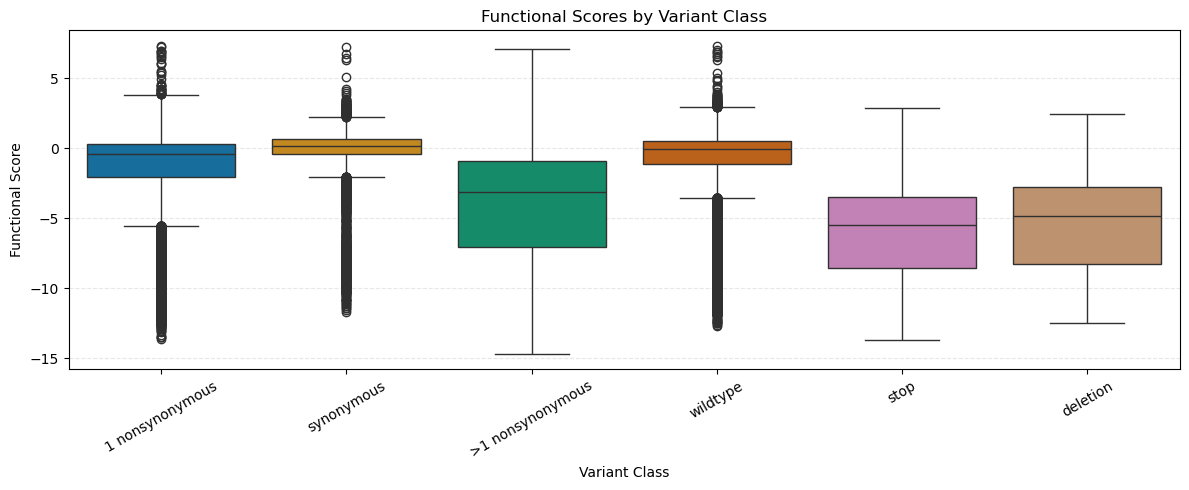

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=func_scores_filtered,
    x="variant_class",
    y="func_score",
    hue="variant_class",      
    palette="colorblind",           
    legend=False
)

plt.xlabel("Variant Class")
plt.ylabel("Functional Score")
plt.title("Functional Scores by Variant Class")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

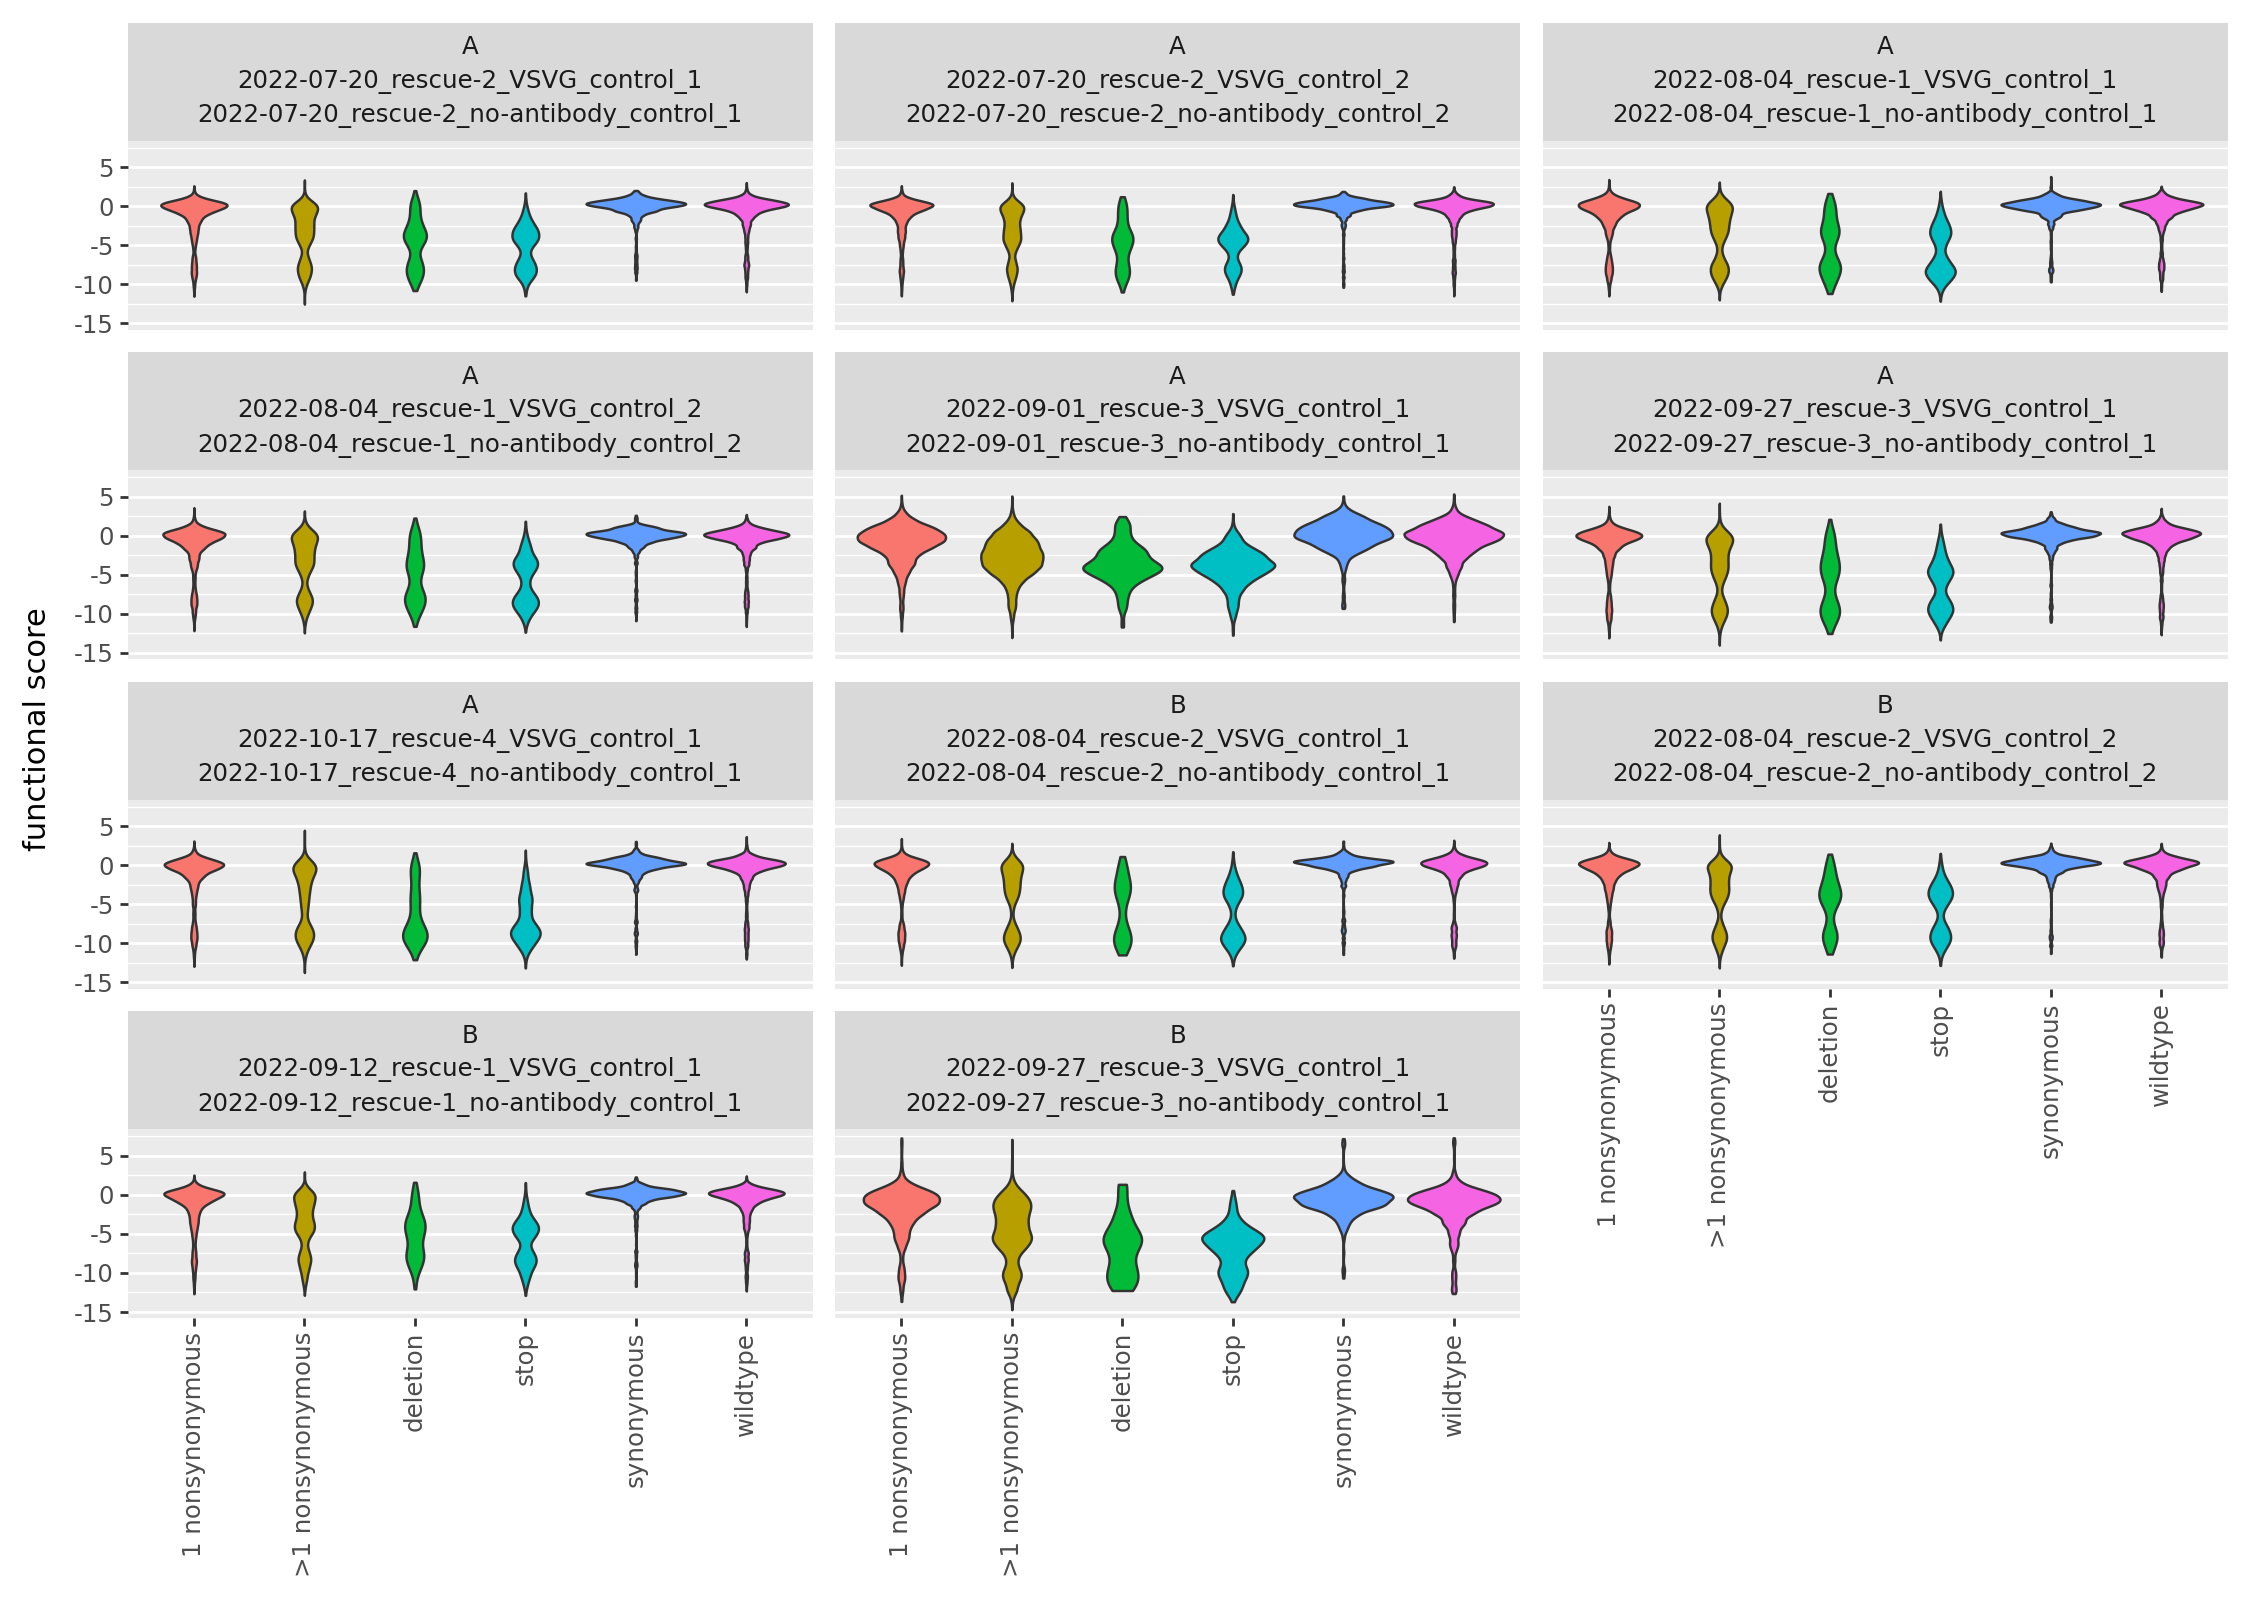

In [16]:
import math
import plotnine as p9


# Fix dtype issues

func_scores_filtered["variant_class"] = (
    func_scores_filtered["variant_class"]
    .astype(str)
)


# Layout

ncols = 3

nrows = math.ceil(
    len(
        func_scores_filtered.groupby(
            [
                "library",
                "pre_sample",
                "post_sample",
            ]
        )
    ) / ncols
)


# Violin plot

p = (
    p9.ggplot(
        func_scores_filtered,
        p9.aes(
            x="variant_class",
            y="func_score",
        ),
    )

    + p9.geom_violin(
        p9.aes(
            fill="variant_class"
        )
    )

    + p9.ylab(
        "functional score"
    )

    + p9.xlab("")

    + p9.facet_wrap(
        "~ library + pre_sample + post_sample",
        ncol=ncols,
    )

    + p9.theme(
        figure_size=(
            3.75 * ncols,
            2 * nrows,
        ),

        axis_text_x=p9.element_text(
            angle=90
        ),

        panel_grid_major_x=p9.element_blank(),
    )

    + p9.scale_fill_discrete(
        guide=None
    )
)


# Draw

p

In [17]:
files = os.listdir(VARIANT_COUNTS_DIR)

for f in files[:20]:
    print(f)

B_2022-09-27_rescue-3_antibody_IDC561_2.0_1.csv
A_2022-10-17_rescue-4_antibody_3BNC117_1.0_1.csv
A_2022-09-01_rescue-3_VSVG_control_1.csv
A_2022-10-17_rescue-4_no-antibody_control_1.csv
A_2022-08-04_rescue-1_no-antibody_control_1.csv
A_2022-07-20_rescue-2_VSVG_control_2.csv
A_2022-07-20_rescue-2_no-antibody_control_1.csv
A_2022-07-20_rescue-2_VSVG_control_1.csv
B_2022-09-12_rescue-1_no-antibody_control_1.csv
A_2022-08-04_rescue-1_no-antibody_control_2.csv
A_2022-07-20_rescue-2_antibody_1-18_2.0_2.csv
B_2022-09-27_rescue-3_antibody_IDC508_2.0_1.csv
A_2022-10-17_rescue-4_antibody_IDC513_7.5_1.csv
A_2022-09-27_rescue-3_antibody_IDC561_2.0_1.csv
A_2022-10-17_rescue-4_antibody_3BNC117_2.0_1.csv
A_2022-09-01_rescue-3_no-antibody_control_2.csv
B_2022-09-27_rescue-3_antibody_IDC508_3.0_1.csv
B_2022-10-11_rescue-4_antibody_IDC513_10.0_1.csv
B_2022-09-27_rescue-3_antibody_IDF033_1.0_1.csv
A_2022-10-17_rescue-4_antibody_IDC513_10.0_1.csv


Index(['barcode', 'count', 'codon_substitutions', 'aa_substitutions',
       'variant_call_support'],
      dtype='object')
Merged shape: (44759, 3)

Pearson correlation
-------------------
r = 0.9571956697657342
p = 0.0


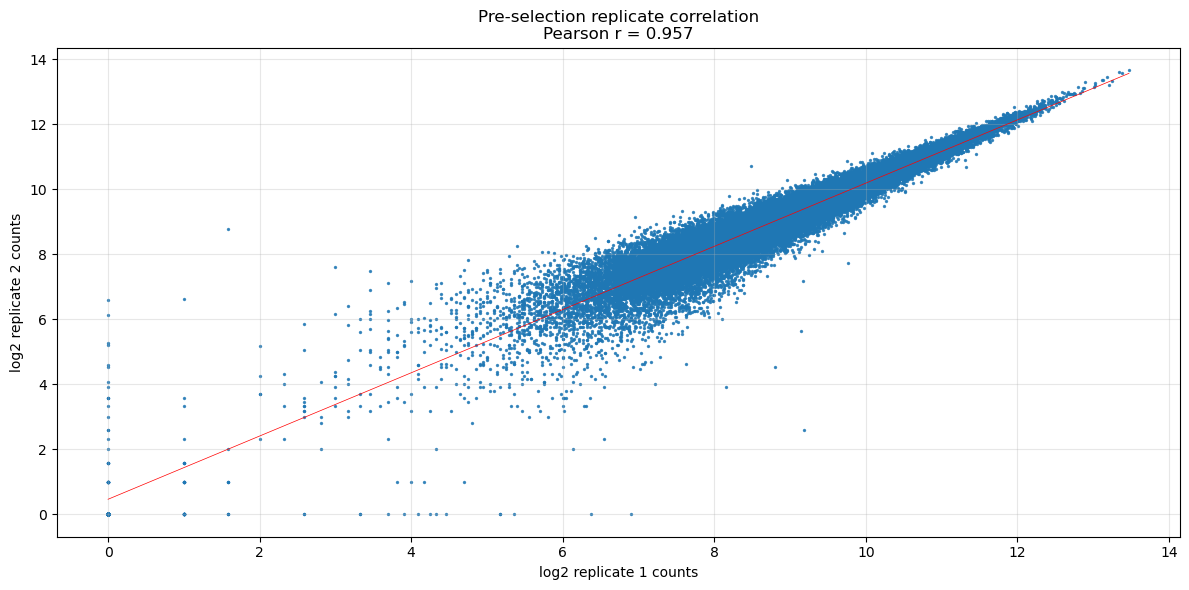

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

rep1 = pd.read_csv(os.path.join(VARIANT_COUNTS_DIR, "A_2022-08-04_rescue-1_VSVG_control_1.csv"))
rep2 = pd.read_csv(os.path.join(VARIANT_COUNTS_DIR, "A_2022-08-04_rescue-1_VSVG_control_2.csv"))

print(rep1.columns)

rep1 = rep1[["barcode", "count"]].rename(columns={"count": "count_rep1"})
rep2 = rep2[["barcode", "count"]].rename(columns={"count": "count_rep2"})

merged = rep1.merge(rep2, on="barcode", how="inner")
print("Merged shape:", merged.shape)

merged["count_rep1"] += 1
merged["count_rep2"] += 1
merged["log_rep1"] = np.log2(merged["count_rep1"])
merged["log_rep2"] = np.log2(merged["count_rep2"])

r, p = pearsonr(merged["log_rep1"], merged["log_rep2"])
print("\nPearson correlation\n-------------------")
print("r =", r)
print("p =", p)

m, b = np.polyfit(merged["log_rep1"], merged["log_rep2"], 1)
x = np.linspace(merged["log_rep1"].min(), merged["log_rep1"].max(), 200)
y = m * x + b

plt.figure(figsize=(12, 6))
plt.scatter(merged["log_rep1"], merged["log_rep2"], alpha=0.8, s=2)
plt.plot(x, y, linewidth=0.5, color="red")
plt.xlabel("log2 replicate 1 counts")
plt.ylabel("log2 replicate 2 counts")
plt.title(f"Pre-selection replicate correlation\nPearson r = {r:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Files found: 72
Replicate pairs: 12
Merged A_2022-10-17_rescue-4_no-antibody_control: (44759, 4)
Merged A_2022-08-04_rescue-1_no-antibody_control: (44759, 4)
Merged A_2022-07-20_rescue-2_VSVG_control: (44759, 4)
Merged A_2022-07-20_rescue-2_no-antibody_control: (44759, 4)
Merged A_2022-07-20_rescue-2_antibody_1-18_2.0: (44759, 4)
Merged A_2022-09-01_rescue-3_no-antibody_control: (44759, 4)
Merged A_2022-08-04_rescue-1_VSVG_control: (44759, 4)
Merged B_2022-09-27_rescue-3_no-antibody_control: (42519, 4)
Merged B_2022-10-11_rescue-4_no-antibody_control: (42519, 4)
Merged A_2022-07-20_rescue-2_antibody_PGT151_2.0: (44759, 4)
Merged B_2022-08-04_rescue-2_VSVG_control: (42519, 4)
Merged B_2022-08-04_rescue-2_no-antibody_control: (42519, 4)

Global Pearson correlation
r = 0.8475089640961156 
p = 0.0


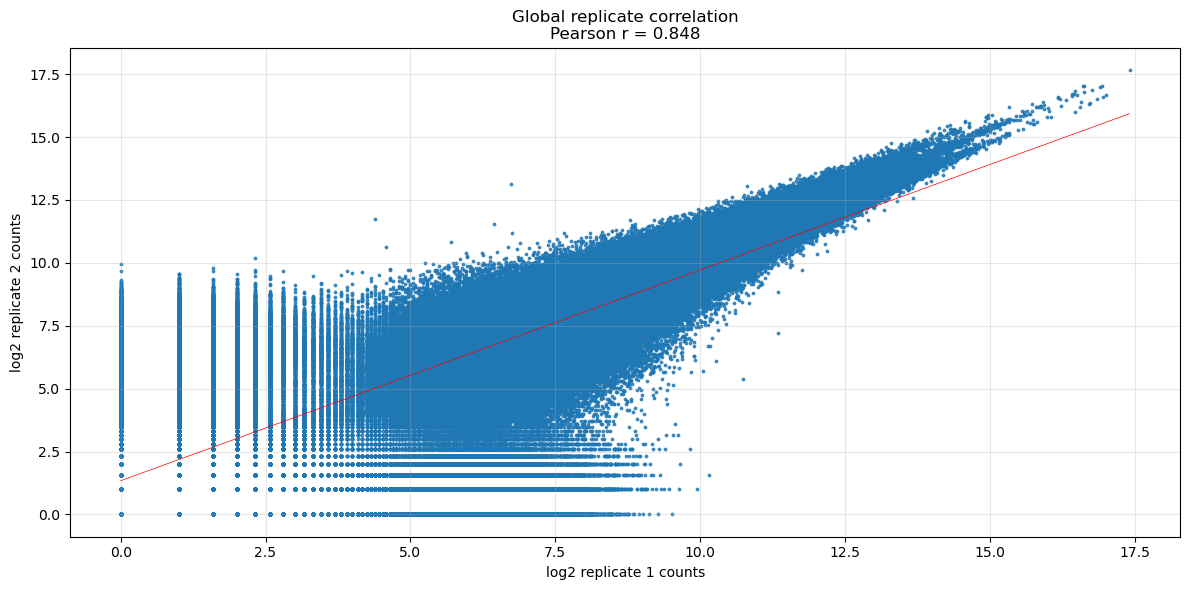

In [19]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

files = glob.glob(os.path.join(VARIANT_COUNTS_DIR, "*.csv"))
print("Files found:", len(files))

replicate_pairs = {}
for f in files:
    filename = os.path.basename(f)
    base = filename.replace("_1.csv", "").replace("_2.csv", "")
    if base not in replicate_pairs:
        replicate_pairs[base] = []
    replicate_pairs[base].append(f)

valid_pairs = {k: v for k, v in replicate_pairs.items() if len(v) == 2}
print("Replicate pairs:", len(valid_pairs))

merged_list = []
for pair_name, pair_files in valid_pairs.items():
    pair_files = sorted(pair_files)
    rep1 = pd.read_csv(pair_files[0])[["barcode", "count"]].rename(columns={"count": "count_rep1"})
    rep2 = pd.read_csv(pair_files[1])[["barcode", "count"]].rename(columns={"count": "count_rep2"})
    merged = rep1.merge(rep2, on="barcode", how="inner")
    merged["sample_pair"] = pair_name
    merged_list.append(merged)
    print(f"Merged {pair_name}:", merged.shape)

all_reps = pd.concat(merged_list, ignore_index=True)
all_reps["count_rep1"] += 1
all_reps["count_rep2"] += 1
all_reps["log_rep1"] = np.log2(all_reps["count_rep1"])
all_reps["log_rep2"] = np.log2(all_reps["count_rep2"])

r, p = pearsonr(all_reps["log_rep1"], all_reps["log_rep2"])
print("\nGlobal Pearson correlation\nr =", r, "\np =", p)

m, b = np.polyfit(all_reps["log_rep1"], all_reps["log_rep2"], 1)
x = np.linspace(all_reps["log_rep1"].min(), all_reps["log_rep1"].max(), 300)
y = m * x + b

plt.figure(figsize=(12, 6))
plt.scatter(all_reps["log_rep1"], all_reps["log_rep2"], alpha=0.8, s=3)
plt.plot(x, y, linewidth=0.5, color="red")
plt.xlabel("log2 replicate 1 counts")
plt.ylabel("log2 replicate 2 counts")
plt.title(f"Global replicate correlation\nPearson r = {r:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

(44751, 3)
Pearson r = 0.7537334647694773


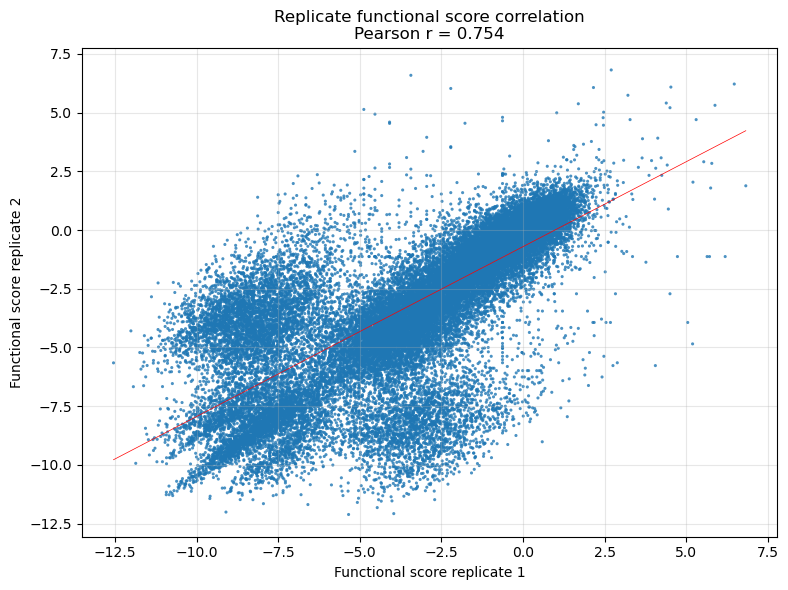

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

rep1 = pd.read_csv(os.path.join(
    FUNC_SCORES_DIR,
    "A_2022-07-20_rescue-2_VSVG_control_1_vs_2022-07-20_rescue-2_no-antibody_control_1_merged_mapped_func_score.csv"
))
rep2 = pd.read_csv(os.path.join(
    FUNC_SCORES_DIR,
    "A_2022-07-20_rescue-2_VSVG_control_2_vs_2022-07-20_rescue-2_no-antibody_control_2_merged_mapped_func_score.csv"
))

rep1 = rep1[["barcode", "func_score"]].rename(columns={"func_score": "func_score_rep1"})
rep2 = rep2[["barcode", "func_score"]].rename(columns={"func_score": "func_score_rep2"})

merged = rep1.merge(rep2, on="barcode", how="inner")
merged = merged.replace([np.inf, -np.inf], np.nan).dropna()
print(merged.shape)

r, p = pearsonr(merged["func_score_rep1"], merged["func_score_rep2"])
print("Pearson r =", r)

m, b = np.polyfit(merged["func_score_rep1"], merged["func_score_rep2"], 1)
x = np.linspace(merged["func_score_rep1"].min(), merged["func_score_rep1"].max(), 200)
y = m * x + b

plt.figure(figsize=(8, 6))
plt.scatter(merged["func_score_rep1"], merged["func_score_rep2"], alpha=0.8, s=5, edgecolor="none")
plt.plot(x, y, linestyle="-", linewidth=0.5, color="red")
plt.xlabel("Functional score replicate 1")
plt.ylabel("Functional score replicate 2")
plt.title(f"Replicate functional score correlation\nPearson r = {r:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Cross-batch functional score correlation
Compares mean functional scores for single-amino-acid substitutions across different experimental dates (batches) within each library. Each scatter plot shows one date pair; the dashed red line is the identity (y = x). High Pearson r indicates reproducibility across batches.

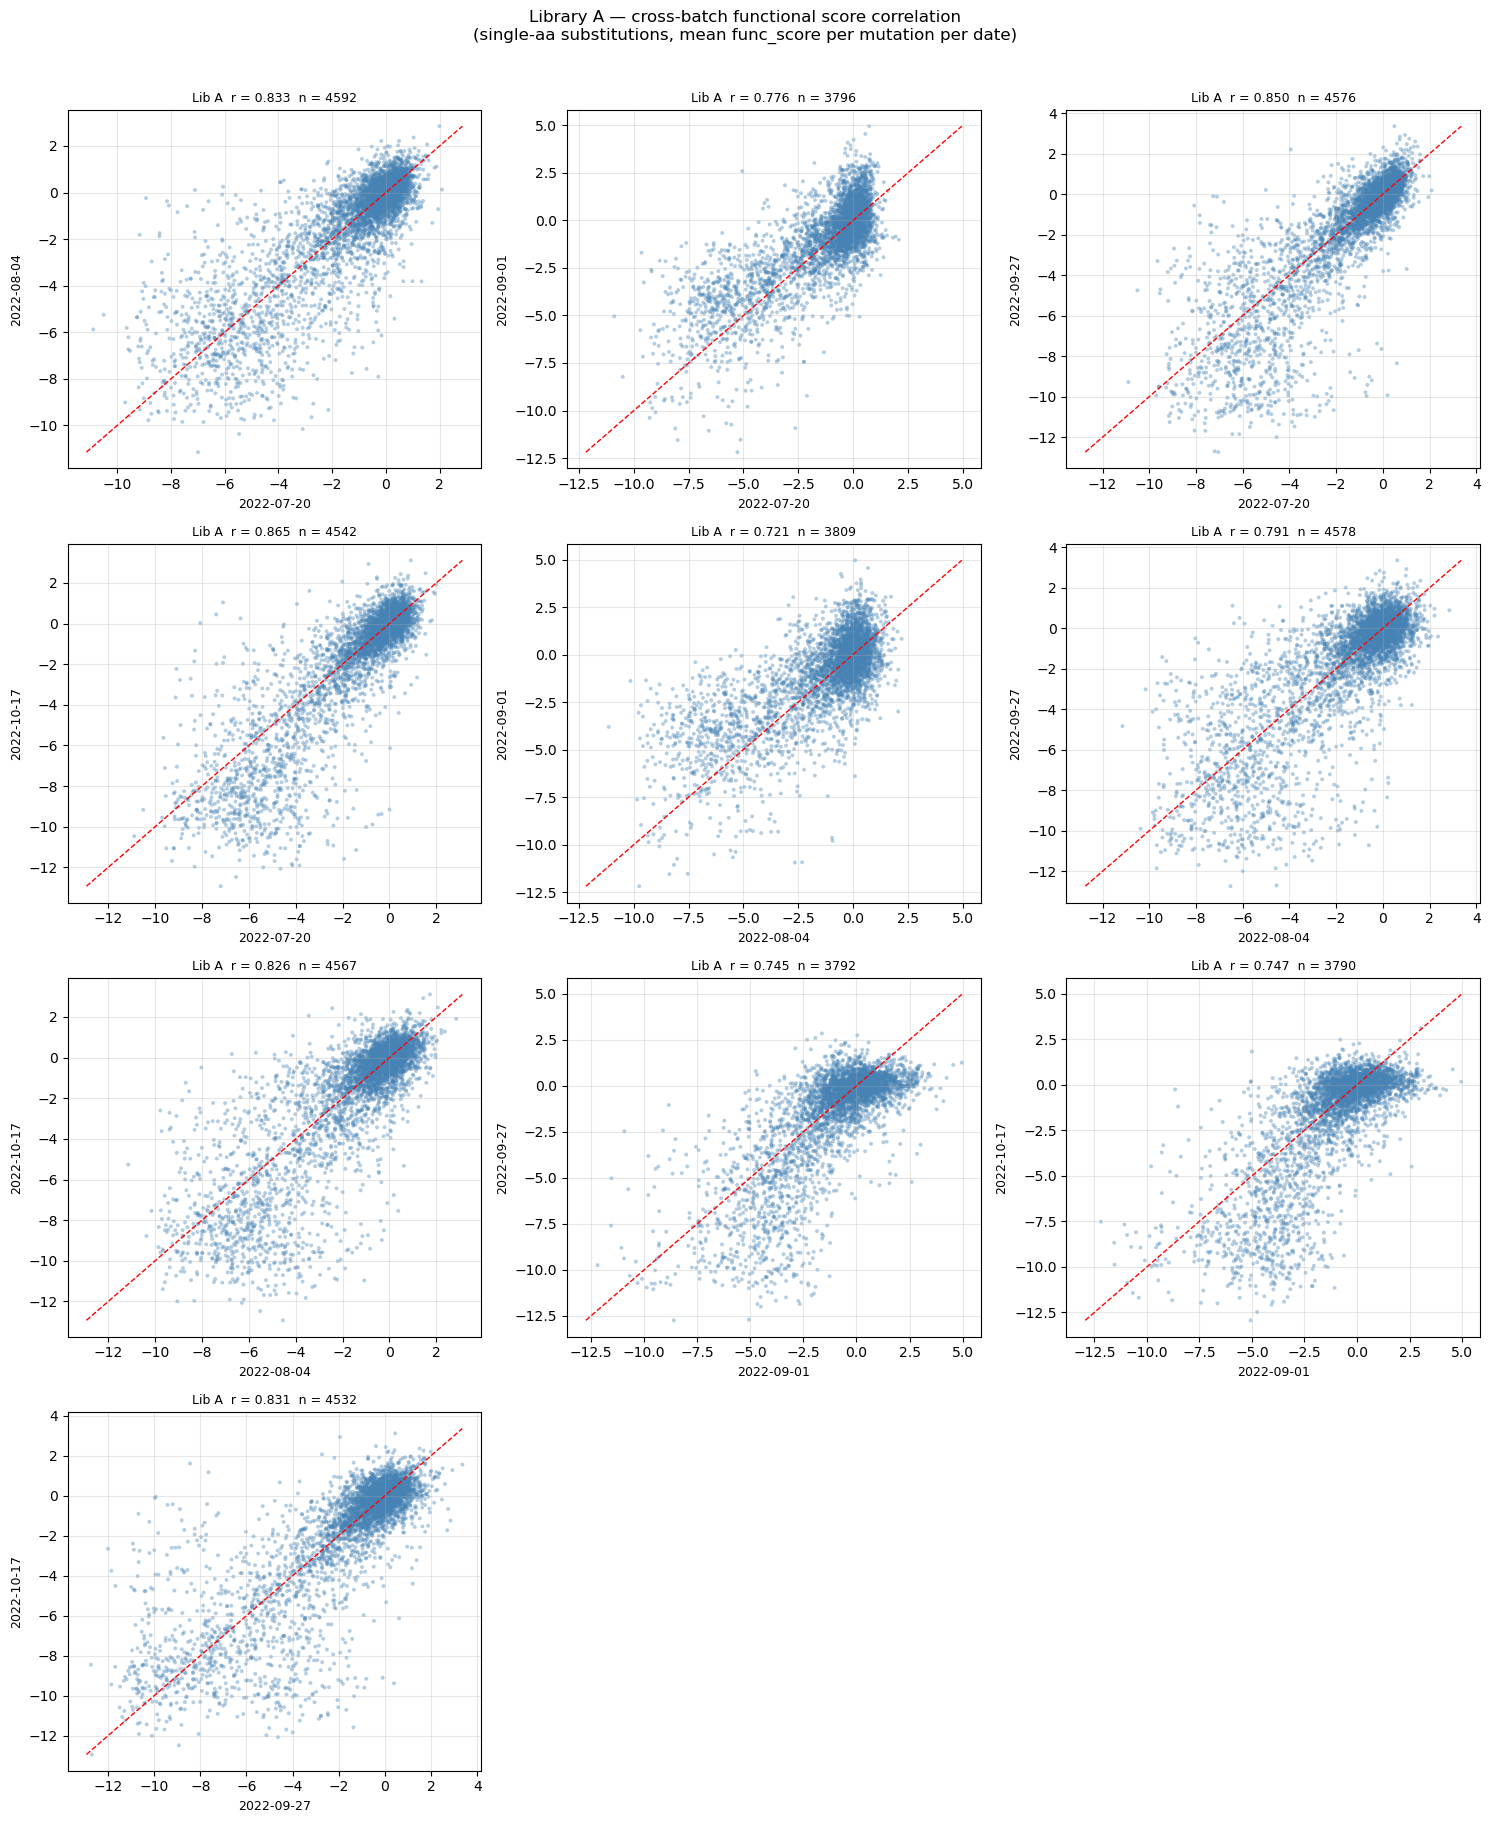

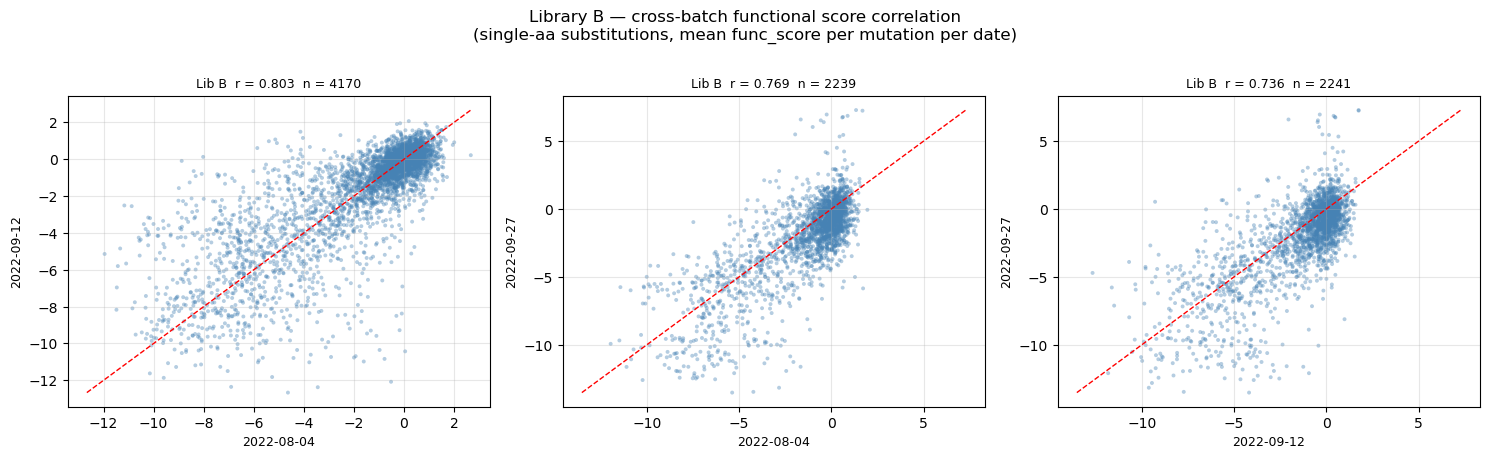

In [21]:
import itertools
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Extract experimental date (YYYY-MM-DD) from pre_sample
fs = func_scores_filtered.copy()
fs["date"] = fs["pre_sample"].str[:10]

# Mean func_score per (library, date, mutation) — single-aa substitutions only
per_mut = (
    fs[fs["n_aa_substitutions"] == 1]
    .groupby(["library", "date", "aa_substitutions_reference"])["func_score"]
    .mean()
    .reset_index()
)

for lib, grp in per_mut.groupby("library"):
    pivot = grp.pivot_table(
        index="aa_substitutions_reference",
        columns="date",
        values="func_score",
    )
    dates = pivot.columns.tolist()
    pairs = list(itertools.combinations(dates, 2))

    if not pairs:
        print(f"Library {lib}: only one date, skipping.")
        continue

    ncols = min(3, len(pairs))
    nrows = math.ceil(len(pairs) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    axes_flat = [ax for row in axes for ax in row]

    for ax, (d1, d2) in zip(axes_flat, pairs):
        sub = pivot[[d1, d2]].dropna()
        if len(sub) < 5:
            ax.set_visible(False)
            continue
        r, _ = pearsonr(sub[d1], sub[d2])
        ax.scatter(sub[d1], sub[d2], alpha=0.4, s=8, color="steelblue", edgecolors="none")
        lims = [min(sub[d1].min(), sub[d2].min()), max(sub[d1].max(), sub[d2].max())]
        ax.plot(lims, lims, "r--", lw=1)
        ax.set_xlabel(d1, fontsize=9)
        ax.set_ylabel(d2, fontsize=9)
        ax.set_title(f"Lib {lib}  r = {r:.3f}  n = {len(sub)}", fontsize=9)
        ax.grid(alpha=0.3)

    for ax in axes_flat[len(pairs):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Library {lib} — cross-batch functional score correlation\n"
        "(single-aa substitutions, mean func_score per mutation per date)",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_52089/3955305829.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_52089/3955305829.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


σ² distribution across all mutations:
count    26753.0000
mean         1.3290
std          4.6998
min          0.0000
25%          0.0043
50%          0.0490
75%          0.2769
max         53.8351
Name: sigma2, dtype: float64


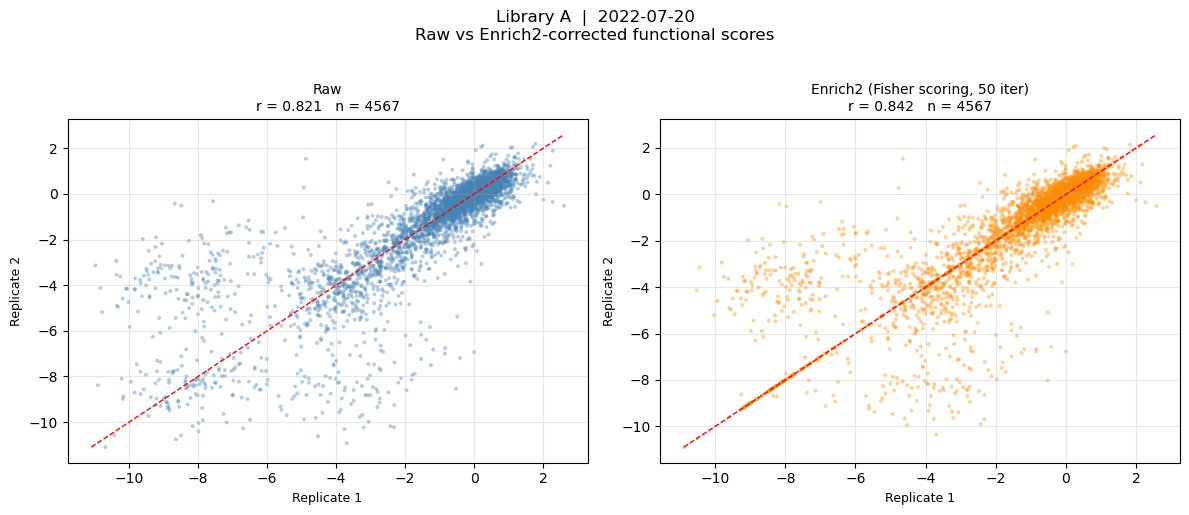

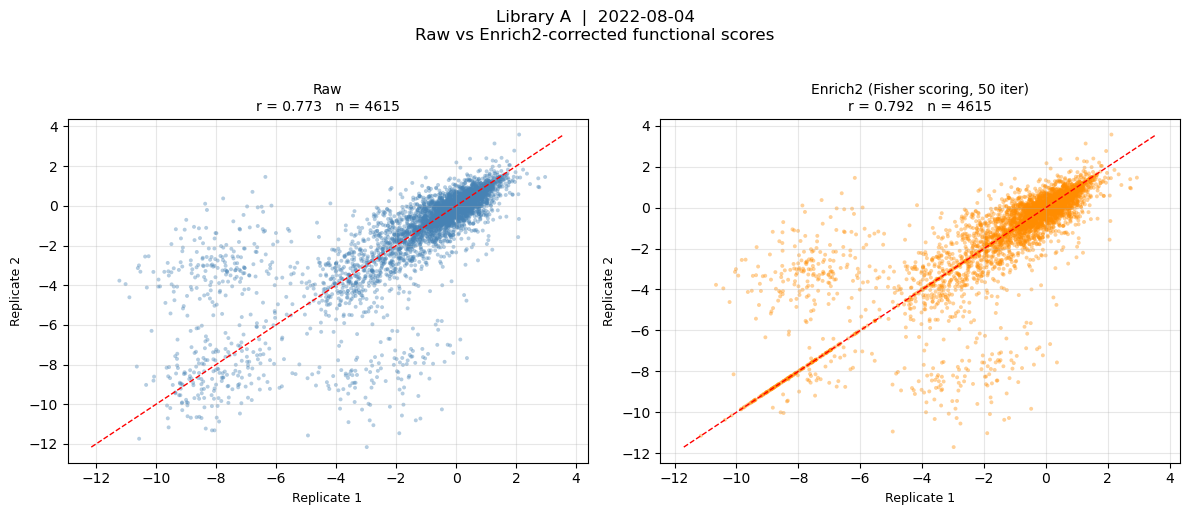

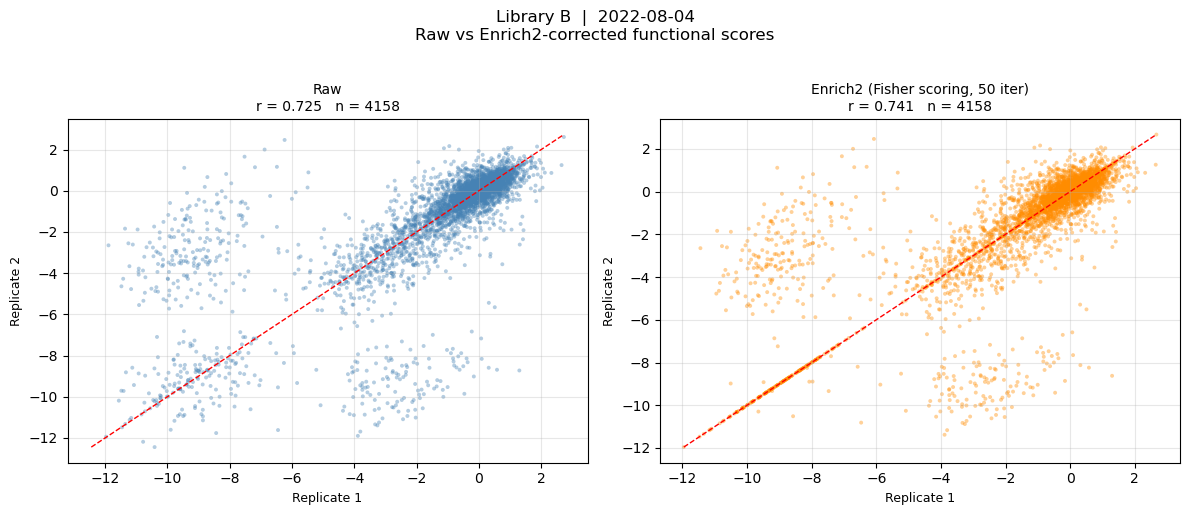

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ── Enrich2 Fisher scoring: exact formula from the paper ─────────────────────
# σ²_{s+1} = σ²_s × Σ[w_i²(β̂_i−β̂)²] / [Σw_i − Σw_i²/Σw_i]
# w_i = 1/(σ²_s + σ²_i),  50 iterations as specified in paper

def enrich2_sigma2(scores, variances, n_iter=50):
    scores    = np.asarray(scores,    dtype=float)
    variances = np.asarray(variances, dtype=float)
    if len(scores) < 2:
        return 0.0
    # initialise with variance of observed scores (avoids starting at 0)
    sigma2 = max(float(np.var(scores, ddof=1)), 1e-8)
    for _ in range(n_iter):
        w      = 1.0 / (sigma2 + variances)       # w_i
        W      = w.sum()                           # Σ w_i
        W2     = (w**2).sum()                      # Σ w_i²
        beta   = np.dot(w, scores) / W             # β̂ (weighted mean)
        num    = np.dot(w**2, (scores - beta)**2)  # Σ w_i²(β̂_i − β̂)²
        denom  = W - W2 / W                        # Σw_i − Σw_i²/Σw_i
        if denom <= 0:
            break
        sigma2_new = max(0.0, sigma2 * num / denom)
        if abs(sigma2_new - sigma2) < 1e-12:
            break
        sigma2 = sigma2_new
    return sigma2


def enrich2_combine(scores, variances):
    """
    Returns per-replicate corrected scores, combined score, SE, and σ².
    Corrected score = partial pooling toward RE combined mean β̂:
      s_r* = β̂ + [σ²/(σ²+v_r)] × (s_r − β̂)
    """
    sigma2    = enrich2_sigma2(scores, variances)
    w         = 1.0 / (sigma2 + variances)
    W         = w.sum()
    beta      = np.dot(w, scores) / W          # RE combined score
    se        = np.sqrt(1.0 / W)               # SE (Screenshot 2 formula)
    shrinkage = sigma2 / (sigma2 + variances)  # per-replicate pooling factor
    corrected = beta + shrinkage * (scores - beta)
    return corrected, beta, se, sigma2

# ── Prepare data ─────────────────────────────────────────────────────────────
fs = func_scores_filtered.copy()
fs["date"]      = fs["pre_sample"].str[:10]
fs["replicate"] = fs["pre_sample"].str[-1]
fs_single = fs[fs["n_aa_substitutions"] == 1].copy()

# Step 1 — aggregate barcodes within each replicate (IVW)
def agg_barcodes(g):
    v = np.where(g["func_score_var"].values <= 0, 1e-10, g["func_score_var"].values)
    w = 1.0 / v
    return pd.Series({
        "func_score_rep":     np.dot(w, g["func_score"].values) / w.sum(),
        "func_score_var_rep": 1.0 / w.sum(),
    })

per_rep = (
    fs_single
    .groupby(["library", "date", "replicate", "aa_substitutions_reference"])
    .apply(agg_barcodes)
    .reset_index()
)

# Step 2 — apply Enrich2 Fisher scoring across replicates per mutation
def apply_enrich2(group):
    if len(group) < 2:
        return group.assign(func_score_enrich2=group["func_score_rep"].values, sigma2=0.0)
    corrected, beta, se, sigma2 = enrich2_combine(
        group["func_score_rep"].values,
        group["func_score_var_rep"].values,
    )
    group = group.copy()
    group["func_score_enrich2"] = corrected
    group["sigma2"]             = sigma2
    return group

per_rep = (
    per_rep
    .groupby(["library", "date", "aa_substitutions_reference"], group_keys=False)
    .apply(apply_enrich2)
)

# ── Keep only dates with both replicates ─────────────────────────────────────
valid_dates = (
    per_rep.groupby(["library", "date"])["replicate"]
    .nunique()
    .pipe(lambda s: s[s == 2])
    .reset_index()[["library", "date"]]
)
data = per_rep.merge(valid_dates, on=["library", "date"])

print("σ² distribution across all mutations:")
print(data["sigma2"].describe().round(4))

# ── Side-by-side plots ────────────────────────────────────────────────────────
for _, row in valid_dates.iterrows():
    lib, date = row["library"], row["date"]
    sub = data[(data["library"] == lib) & (data["date"] == date)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, score_col, label, color in [
        (axes[0], "func_score_rep",    "Raw",                              "steelblue"),
        (axes[1], "func_score_enrich2","Enrich2 (Fisher scoring, 50 iter)","darkorange"),
    ]:
        pivot = (
            sub.pivot_table(
                index="aa_substitutions_reference",
                columns="replicate",
                values=score_col,
            )[["1", "2"]].dropna()
        )
        r, _ = pearsonr(pivot["1"], pivot["2"])
        ax.scatter(pivot["1"], pivot["2"], alpha=0.4, s=8, color=color, edgecolors="none")
        lims = [min(pivot["1"].min(), pivot["2"].min()), max(pivot["1"].max(), pivot["2"].max())]
        ax.plot(lims, lims, "r--", lw=1)
        ax.set_xlabel("Replicate 1", fontsize=9)
        ax.set_ylabel("Replicate 2", fontsize=9)
        ax.set_title(f"{label}\nr = {r:.3f}   n = {len(pivot)}", fontsize=10)
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Library {lib}  |  {date}\nRaw vs Enrich2-corrected functional scores",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
